# Predictive Maintenance in NASA C-MAPSS Turbofan Engines

Hybrid CNN-LSTM and feature-engineering experiments for Remaining Useful Life (RUL) prediction on the FD001 subset.

**Cleanup note:** This version preserves the original experiment logic and result-producing code. Only a diagnostic file-listing cell was removed, and section headings were added for readability.


## 1. Data Loading

Load and extract the NASA C-MAPSS FD001 training data.


In [ ]:
from pathlib import Path
import zipfile
import os
import pandas as pd
import numpy as np

zip_candidates = [
    Path("data/CMAPSSData.zip"),
    Path("../data/CMAPSSData.zip"),
    Path("/content/data/CMAPSSData.zip"),
    Path("/content/CMAPSSData.zip"),
]

zip_path = next((p for p in zip_candidates if p.exists()), None)

if zip_path is None:
    raise FileNotFoundError(
        "CMAPSSData.zip bulunamadı.\n"
        "Repo kullanıyorsan dosyayı data/CMAPSSData.zip konumuna koy.\n"
        "Colab kullanıyorsan ZIP dosyasını /content veya /content/data altına yükleyebilirsin."
    )

# Extract next to the ZIP file so all dataset files stay under data/
extract_path = zip_path.parent / "cmapss_data"
extract_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# ZIP archives may contain an additional nested folder.
# Find the required FD001 files recursively instead of assuming
# a specific internal archive structure.
def find_dataset_file(filename):
    matches = list(extract_path.rglob(filename))
    if not matches:
        raise FileNotFoundError(
            f"{filename} CMAPSSData.zip içinde bulunamadı."
        )
    return matches[0]

train_path = find_dataset_file("train_FD001.txt")
test_path = find_dataset_file("test_FD001.txt")
rul_path = find_dataset_file("RUL_FD001.txt")

print("Dataset ZIP:", zip_path.resolve())
print("Train file :", train_path.resolve())
print("Test file  :", test_path.resolve())
print("RUL file   :", rul_path.resolve())

# Column names
col_names = [
    "engine_id", "cycle", "setting1", "setting2", "setting3"
] + [f"sensor{i}" for i in range(1, 22)]

# Load FD001 training data
df = pd.read_csv(
    train_path,
    sep=r"\s+",
    header=None,
    names=col_names
)

print(f"\nVeri Seti Başarıyla Yüklendi! Boyut: {df.shape}")
df.head()


Dataset ZIP: /content/CMAPSSData.zip
Train file : /content/cmapss_data/train_FD001.txt
Test file  : /content/cmapss_data/test_FD001.txt
RUL file   : /content/cmapss_data/RUL_FD001.txt

Veri Seti Başarıyla Yüklendi! Boyut: (20631, 26)


,engine_id,cycle,setting1,setting2,setting3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


## 2. Initial Data Inspection and Cleaning

Inspect variance and remove constant sensor columns.


In [23]:
# 1. Her bir sensörün standart sapmasını (std) inceleyelim
print("--- Sensörlerin Standart Sapma Değerleri ---")
print(df.describe().loc['std'])

# 2. Standart sapması 0 olan (hiç değişmeyen) sütunları otomatik bulalım (Kaçış karakteri düzeltildi)
constant_columns = [col for col in df.columns if df[col].std() == 0]
print("\nHiç değişmeyen (Varyansı 0 olan) ve elenecek sütunlar:", constant_columns)

# 3. Bu sabit sütunları veri setimizden kalıcı olarak düşürelim
df_drop = df.drop(columns=constant_columns)
print(f"Sabit sütunlar elendikten sonra yeni veri boyutu: {df_drop.shape}")

# 4. Veri kümesindeki motorların (engine_id) kaç çevrim yaşadığını görelim
max_cycles = df_drop.groupby('engine_id')['cycle'].max()
print("\nİlk 5 motorun arızalanmadan önceki maksimum uçuş/çevrim sayısı:")
print(max_cycles.head())

print(f"\nEn kısa ömürlü motor {max_cycles.min()} çevrim, en uzun ömürlü motor {max_cycles.max()} çevrim yaşamış.")

--- Sensörlerin Standart Sapma Değerleri ---
engine_id    2.922763e+01
cycle        6.888099e+01
setting1     2.187313e-03
setting2     2.930621e-04
setting3     0.000000e+00
sensor1      6.537152e-11
sensor2      5.000533e-01
sensor3      6.131150e+00
sensor4      9.000605e+00
sensor5      3.394700e-12
sensor6      1.388985e-03
sensor7      8.850923e-01
sensor8      7.098548e-02
sensor9      2.208288e+01
sensor10     4.660829e-13
sensor11     2.670874e-01
sensor12     7.375534e-01
sensor13     7.191892e-02
sensor14     1.907618e+01
sensor15     3.750504e-02
sensor16     1.556432e-14
sensor17     1.548763e+00
sensor18     0.000000e+00
sensor19     0.000000e+00
sensor20     1.807464e-01
sensor21     1.082509e-01
Name: std, dtype: float64

Hiç değişmeyen (Varyansı 0 olan) ve elenecek sütunlar: ['setting3', 'sensor18', 'sensor19']
Sabit sütunlar elendikten sonra yeni veri boyutu: (20631, 23)

İlk 5 motorun arızalanmadan önceki maksimum uçuş/çevrim sayısı:
engine_id
1    192
2    287
3    

## 3. Linear RUL Target Construction

Construct the initial linear Remaining Useful Life target.


In [24]:
# 1. Her motorun maksimum döngü sayısını veri setine bir sütun olarak ekleyelim
# Her satırın ait olduğu motorun toplamda ne kadar yaşadığını bilmesi gerekir
df_drop = df_drop.merge(max_cycles.to_frame(name='max_cycle'), left_on='engine_id', right_index=True)

# 2. Doğrusal RUL (Remaining Useful Life) değerini hesaplayalım
# Formül: max_cycle - mevcut_cycle
df_drop['RUL'] = df_drop['max_cycle'] - df_drop['cycle']

# 3. max_cycle sütununa artık ihtiyacımız kalmadı, düşürelim
df_drop = df_drop.drop(columns=['max_cycle'])

# 4. İşlemin doğruluğunu kontrol etmek için 1. motorun son 5 satırına bakalım
# RUL değerinin sıfıra doğru azaldığını görmeliyiz
print("1. Motorun Son 5 Çevrimi ve Hesaplanan RUL Değerleri:")
print(df_drop[df_drop['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail())

1. Motorun Son 5 Çevrimi ve Hesaplanan RUL Değerleri:
     engine_id  cycle  RUL
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0


## 4. Low-Variance Filtering and Normalization

Remove low-variance variables and apply the original MinMax scaling procedure.


In [25]:
from sklearn.preprocessing import MinMaxScaler

# 1. Varyansı çok düşük (0.01'in altında) olan diğer gizli sabit sütunları tespit edelim
low_variance_cols = [col for col in df_drop.columns if df_drop[col].std() < 0.01 and col not in ['engine_id', 'cycle', 'RUL']]
print("Düşük varyans nedeniyle elenen diğer gizli sabit sütunlar:", low_variance_cols)

# Veri setimizden bu sütunları da uçuralım
df_clean = df_drop.drop(columns=low_variance_cols)

# 2. Normalize edilecek sensör ve ayar sütunlarını seçelim
# engine_id, cycle ve hedef değişkenimiz olan RUL normalize EDİLMEZ.
features_to_scale = [col for col in df_clean.columns if col not in ['engine_id', 'cycle', 'RUL']]

# 3. Min-Max Scaler uygulayalım (Veriyi 0 ile 1 arasına sıkıştırır)
scaler = MinMaxScaler()
df_clean[features_to_scale] = scaler.fit_transform(df_clean[features_to_scale])

print(f"\nTemizlik ve Normalizasyon sonrası yeni veri boyutu: {df_clean.shape}")
print("\nNormalize edilmiş ilk 3 satıra göz atalım:")
df_clean[['engine_id', 'cycle'] + features_to_scale[:4] + ['RUL']].head(3)

Düşük varyans nedeniyle elenen diğer gizli sabit sütunlar: ['setting1', 'setting2', 'sensor1', 'sensor5', 'sensor6', 'sensor10', 'sensor16']

Temizlik ve Normalizasyon sonrası yeni veri boyutu: (20631, 17)

Normalize edilmiş ilk 3 satıra göz atalım:


,engine_id,cycle,sensor2,sensor3,sensor4,sensor7,RUL
0,1,1,0.183735,0.406802,0.309757,0.726248,191
1,1,2,0.283133,0.453019,0.352633,0.628019,190
2,1,3,0.343373,0.369523,0.370527,0.710145,189


## 5. Sliding-Window Sequence Construction

Transform engine trajectories into 30-cycle sequences.


In [26]:
def reshape_to_windows(df, sequence_length, feature_cols):
    """
    Veriyi motor bazında gruplayarak belirlenen pencere genişliğine göre 3 boyutlu matrise dönüştürür.
    """
    X_list = []
    y_list = []

    # Her motoru kendi içinde bağımsızca işliyoruz
    for engine_id in df['engine_id'].unique():
        engine_df = df[df['engine_id'] == engine_id]

        # Motorun toplam ömrü pencere genişliğinden küçükse o motoru pas geçiyoruz
        if engine_df.shape[0] < sequence_length:
            continue

        # Ham sensör verilerini alıyoruz
        engine_features = engine_df[feature_cols].values
        # Hedef değişken (RUL) değerlerini alıyoruz
        engine_rul = engine_df['RUL'].values

        # Kayan pencere oluşturma mekanizması
        for i in range(sequence_length, engine_df.shape[0] + 1):
            X_list.append(engine_features[i - sequence_length:i])
            # Pencerenin bittiği andaki RUL değerini hedef olarak alıyoruz
            y_list.append(engine_rul[i - 1])

    return np.array(X_list), np.array(y_list)

# 1. Kullanacağımız aktif dinamik öznitelikleri seçelim (engine_id, cycle ve RUL hariç hepsi)
feature_columns = [col for col in df_clean.columns if col not in ['engine_id', 'cycle', 'RUL']]

# 2. Pencere genişliğini 30 olarak belirleyelim (Son 30 çevrime bakarak tahmin yapacak)
sequence_length = 30

# 3. Fonksiyonu çalıştırıp verimizi 3 boyutlu matrislere dönüştürelim
X, y = reshape_to_windows(df_clean, sequence_length, feature_columns)

print(f"Giriş Verisinin (X) Yeni Boyutu [Örnek Sayısı, Pencere Genişliği, Özellik Sayısı]: {X.shape}")
print(f"Hedef Değişkenin (y) Boyutu: {y.shape}")

Giriş Verisinin (X) Yeni Boyutu [Örnek Sayısı, Pencere Genişliği, Özellik Sayısı]: (17731, 30, 14)
Hedef Değişkenin (y) Boyutu: (17731,)


## 6. Baseline LSTM with Linear RUL

Train the original baseline LSTM model.


In [27]:
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Veriyi %80 Eğitim, %20 Doğrulama (Validation) olarak bölelim
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Eğitim Kümesi Boyutu: {X_train.shape}")
print(f"Doğrulama Kümesi Boyutu: {X_val.shape}")

# 2. Model Mimarisini Tanımlayalım
model = Sequential([
    # İlk LSTM katmanı - Verinin zaman boyutunu işler
    LSTM(units=64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2), # Aşırı öğrenmeyi önlemek için %20 nöron kapama

    # İkinci LSTM katmanı - Daha derin özellikleri öğrenir
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),

    # Tam bağlantılı (Dense) katmanlar
    Dense(units=16, activation='relu'),
    # Çıkış katmanı: Tek bir sayı (RUL) tahmin edeceği için aktivasyon fonksiyonu yok (Linear)
    Dense(units=1)
])

# 3. Modeli Derleyelim (Kayıp fonksiyonu olarak MSE, optimizasyon için Adam kullanıyoruz)
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# 4. Erken Durdurma (Early Stopping) Ekleyelim
# Doğrulama kaybı (val_loss) 5 epoch boyunca iyileşmezse eğitimi otomatik durdurur
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.summary()

# 5. Modeli Eğitelim
print("\nModel Eğitimi Başlıyor...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Eğitim Kümesi Boyutu: (14184, 30, 14)
Doğrulama Kümesi Boyutu: (3547, 30, 14)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 64)         │        20,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,185 (129.63 KB)

 Trainable params: 33,185 (129.63 KB)

 Non-trainable params: 0 (0.00 B)


Model Eğitimi Başlıyor...
Epoch 1/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 13s 45ms/step - loss: 8832.6602 - mae: 74.0033 - val_loss: 5336.2573 - val_mae: 56.0508
Epoch 2/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 4270.4043 - mae: 51.9061 - val_loss: 3829.5640 - val_mae: 50.3377
Epoch 3/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 3904.0347 - mae: 50.9143 - val_loss: 3825.6296 - val_mae: 50.4876
Epoch 4/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 3892.8750 - mae: 50.7649 - val_loss: 3825.8633 - val_mae: 50.4353
Epoch 5/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 38ms/step - loss: 3906.1824 - mae: 50.8627 - val_loss: 3827.8083 - val_mae: 50.3671
Epoch 6/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 43ms/step - loss: 3904.0015 - mae: 50.8056 - val_loss: 3826.5188 - val_mae: 50.5617
Epoch 7/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 3897.6836 - mae: 50.8847 - val_loss: 3825.5444 - val_mae: 50.4615
Epoch 8/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 3659.1077 - mae: 48.

## 7. Baseline Evaluation

Evaluate the linear-RUL baseline using RMSE, MAE, and R².


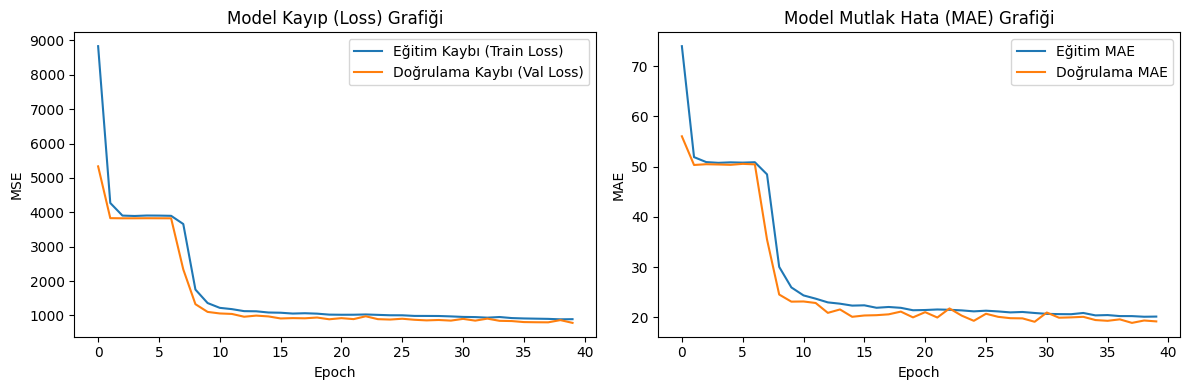

111/111 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step

================ MODEL PERFORMANS SONUÇLARI ================
Root Mean Squared Error (RMSE): 27.98 Çevrim
Mean Absolute Error (MAE): 19.18 Çevrim
R2 Score (Açıklayıcılık Oranı): 0.7953


In [30]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
# 1. Eğitim ve Doğrulama Kayıplarını Grafiğe Dökme
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Model Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# 2. MAE Grafiklendirmesi
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Eğitim MAE')
plt.plot(history.history['val_mae'], label='Doğrulama MAE')
plt.title('Model Mutlak Hata (MAE) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Doğrulama Kümesi Üzerinde Tahmin Yapma
y_pred = model.predict(X_val)

# Metriklerin Hesaplanması
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
mae = mean_absolute_error(y_val, y_pred)
r2 = r2_score(y_val, y_pred)

print("\n================ MODEL PERFORMANS SONUÇLARI ================")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2:.4f}")
print("=============================================================")

## 8. Piecewise RUL Experiment

Replace the linear target with the original capped piecewise RUL formulation.


In [31]:
# 1. Temizlenmiş veri setimizin bir kopyasını alalım
df_piecewise = df_clean.copy()

# Orijinal doğrusal RUL değerlerini geri getirmek için df_drop'tan RUL'u tekrar düzgünce çekelim
# Çünkü df_clean içinde normalize edilmiş sensörler var ama RUL ham kalmıştı.
# Maksimum RUL değerini 130 ile sınırlıyoruz (Piecewise RUL)
MAX_RUL = 130
df_piecewise['RUL'] = df_drop['RUL'].apply(lambda x: MAX_RUL if x > MAX_RUL else x)

# 2. İşlemin doğruluğunu teyit etmek için 1. motorun ilk ve son satırlarına bakalım
print("--- 1. Motorun Yeni Parçalı RUL Değerleri (İlk 5 Satır) ---")
print(df_piecewise[df_piecewise['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].head())

print("\n--- 1. Motorun Yeni Parçalı RUL Değerleri (Son 5 Satır) ---")
print(df_piecewise[df_piecewise['engine_id'] == 1][['engine_id', 'cycle', 'RUL']].tail())

# 3. Yeni etiketlerle pencereleme fonksiyonunu tekrar çalıştıralım
X_p, y_p = reshape_to_windows(df_piecewise, sequence_length=30, feature_cols=feature_columns)

# 4. Eğitim ve Doğrulama kümelerine bölme
X_train_p, X_val_p, y_train_p, y_val_p = train_test_split(X_p, y_p, test_size=0.2, random_state=42)

# 5. Tamamen yeni ve temiz bir LSTM modeli inşa edelim
model_p = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train_p.shape[1], X_train_p.shape[2])),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

model_p.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
early_stop_p = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 6. Yeni modeli eğitelim
print("\nParçalı (Piecewise) RUL Modeli Eğitimi Başlıyor...")
history_p = model_p.fit(
    X_train_p, y_train_p,
    validation_data=(X_val_p, y_val_p),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_p],
    verbose=1
)

--- 1. Motorun Yeni Parçalı RUL Değerleri (İlk 5 Satır) ---
   engine_id  cycle  RUL
0          1      1  130
1          1      2  130
2          1      3  130
3          1      4  130
4          1      5  130

--- 1. Motorun Yeni Parçalı RUL Değerleri (Son 5 Satır) ---
     engine_id  cycle  RUL
187          1    188    4
188          1    189    3
189          1    190    2
190          1    191    1
191          1    192    0

Parçalı (Piecewise) RUL Modeli Eğitimi Başlıyor...
Epoch 1/40


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


222/222 ━━━━━━━━━━━━━━━━━━━━ 16s 42ms/step - loss: 5394.0430 - mae: 62.2163 - val_loss: 2552.2383 - val_mae: 43.7701
Epoch 2/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - loss: 2043.7024 - mae: 39.9739 - val_loss: 1865.6005 - val_mae: 38.2561
Epoch 3/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 89ms/step - loss: 1934.2539 - mae: 38.8606 - val_loss: 1865.5853 - val_mae: 38.2612
Epoch 4/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 24s 106ms/step - loss: 1941.3842 - mae: 38.9499 - val_loss: 1866.4869 - val_mae: 38.2135
Epoch 5/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 36s 84ms/step - loss: 1930.8235 - mae: 38.8183 - val_loss: 1865.5966 - val_mae: 38.2701
Epoch 6/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 18s 79ms/step - loss: 1928.1605 - mae: 38.7359 - val_loss: 1865.7155 - val_mae: 38.2424
Epoch 7/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - loss: 1934.9384 - mae: 38.8681 - val_loss: 1866.2791 - val_mae: 38.2188
Epoch 8/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - loss: 1933.9119 - mae: 38.8050 - val_loss: 1866.4869 - val_

## 9. Piecewise RUL Evaluation

Evaluate the piecewise-RUL model.


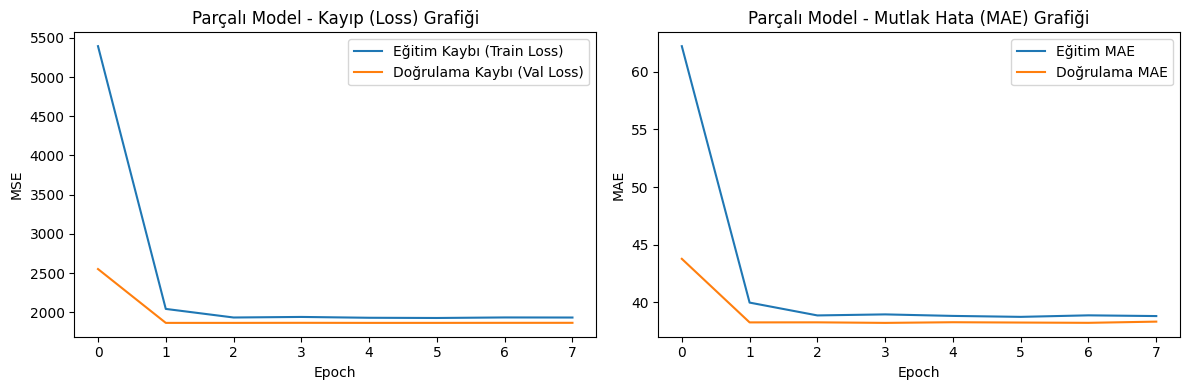

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

================ PARÇALI (PIECEWISE) MODEL PERFORMANSI ================
Root Mean Squared Error (RMSE): 43.19 Çevrim
Mean Absolute Error (MAE): 38.26 Çevrim
R2 Score (Açıklayıcılık Oranı): -0.0000


In [32]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Parçalı RUL Modelinin Eğitim ve Doğrulama Kayıplarını Grafiğe Dökme
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_p.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history_p.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Parçalı Model - Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

# 2. Parçalı Model MAE Grafiklendirmesi
plt.subplot(1, 2, 2)
plt.plot(history_p.history['mae'], label='Eğitim MAE')
plt.plot(history_p.history['val_mae'], label='Doğrulama MAE')
plt.title('Parçalı Model - Mutlak Hata (MAE) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 3. Parçalı Model ile Doğrulama Kümesi Üzerinde Tahmin Yapma
y_pred_p = model_p.predict(X_val_p)

# Yeni Metriklerin Hesaplanması
rmse_p = np.sqrt(mean_squared_error(y_val_p, y_pred_p))
mae_p = mean_absolute_error(y_val_p, y_pred_p)
r2_p = r2_score(y_val_p, y_pred_p)

print("\n================ PARÇALI (PIECEWISE) MODEL PERFORMANSI ================")
print(f"Root Mean Squared Error (RMSE): {rmse_p:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae_p:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2_p:.4f}")
print("=======================================================================")

## 10. Initial Statistical Feature Engineering

Generate the first rolling-statistics feature set.


In [33]:
import pandas as pd
import numpy as np

# 1. Üzerinde oynayacağımız temiz veri setinin kopyasını alalım
df_fe = df_clean.copy()

# Orijinal doğrusal olmayan Parçalı RUL'u bu veri setine de sabitleyelim
df_fe['RUL'] = df_drop['RUL'].apply(lambda x: 130 if x > 130 else x)

# 2. İstatistiksel öznitelik türeteceğimiz dinamik sensörleri seçelim
features = [col for col in df_fe.columns if col not in ['engine_id', 'cycle', 'RUL']]

print("Öznitelik türetilecek ana sensör sayısı:", len(features))

# 3. Kayan Pencere İstatistiklerini Hesaplama (Pencere genişliği: 5 ve 10 çevrimlik kısa/orta vadeli trendler)
# Genelde 5 ve 10'luk pencereler anlık trend değişimlerini yakalamakta çok iyidir
window_sizes = [5, 10]

for w in window_sizes:
    print(f"{w} çevrimlik hareketli istatistikler hesaplanıyor...")

    # Her motoru kendi içinde gruplayarak hareketli ortalama (mean) hesaplama
    df_mean = df_fe.groupby('engine_id')[features].rolling(window=w, min_periods=1).mean().reset_index(level=0, drop=True)
    df_mean.columns = [f"{col}_roll_mean_{w}" for col in features]

    # Her motoru kendi içinde gruplayarak hareketli standart sapma (std) hesaplama (ilk adımlar için 0 dolgusuyla)
    df_std = df_fe.groupby('engine_id')[features].rolling(window=w, min_periods=1).std().reset_index(level=0, drop=True).fillna(0)
    df_std.columns = [f"{col}_roll_std_{w}" for col in features]

    # Türetilen yeni özellikleri ana tabloya yanyana ekliyoruz
    df_fe = pd.concat([df_fe, df_mean, df_std], axis=1)

print(f"\nVeriyle çokça uğraştıktan sonra yeni sütun sayısı: {df_fe.shape[1]}")
print(f"Yeni Veri Seti Boyutu: {df_fe.shape}")

Öznitelik türetilecek ana sensör sayısı: 14
5 çevrimlik hareketli istatistikler hesaplanıyor...
10 çevrimlik hareketli istatistikler hesaplanıyor...

Veriyle çokça uğraştıktan sonra yeni sütun sayısı: 73
Yeni Veri Seti Boyutu: (20631, 73)


## 11. Feature-Engineered LSTM

Train the original LSTM using the enriched feature representation.


In [34]:
# 1. Giriş özniteliklerini güncelleyelim (Sadece türetilenler ve ham dinamik sensörler)
# engine_id, cycle ve RUL'u yine dışarıda bırakıyoruz
feature_columns_fe = [col for col in df_fe.columns if col not in ['engine_id', 'cycle', 'RUL']]
print(f"Modele girecek toplam öznitelik sayısı: {len(feature_columns_fe)}")

# 2. 3 Boyutlu pencereleri (Sliding Window) zenginleştirilmiş veri setiyle yeniden oluşturalım
X_fe, y_fe = reshape_to_windows(df_fe, sequence_length=30, feature_cols=feature_columns_fe)

# 3. Veriyi %80 Eğitim, %20 Doğrulama olarak bölelim
X_train_fe, X_val_fe, y_train_fe, y_val_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=42)

print(f"\nYeni Giriş Verisi (X_train_fe) Boyutu: {X_train_fe.shape}")
print(f"Yeni Doğrulama Verisi (X_val_fe) Boyutu: {X_val_fe.shape}")

# 4. Model Mimarisini Tanımlayalım (input_shape yeni özellik sayısına göre güncellendi)
model_fe = Sequential([
    LSTM(units=64, return_sequences=True, input_shape=(X_train_fe.shape[1], X_train_fe.shape[2])),
    Dropout(0.2),
    LSTM(units=32, return_sequences=False),
    Dropout(0.2),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

# 5. Modeli derleyip erken durdurmayı bağlayalım
model_fe.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
early_stop_fe = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# 6. Eğitimi başlatalım
print("\nZenginleştirilmiş (Feature Engineered) Model Eğitimi Başlıyor...")
history_fe = model_fe.fit(
    X_train_fe, y_train_fe,
    validation_data=(X_val_fe, y_val_fe),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_fe],
    verbose=1
)

Modele girecek toplam öznitelik sayısı: 70

Yeni Giriş Verisi (X_train_fe) Boyutu: (14184, 30, 70)
Yeni Doğrulama Verisi (X_val_fe) Boyutu: (3547, 30, 70)

Zenginleştirilmiş (Feature Engineered) Model Eğitimi Başlıyor...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - loss: 5561.7310 - mae: 63.2785 - val_loss: 2850.3611 - val_mae: 45.7986
Epoch 2/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 43ms/step - loss: 2160.7327 - mae: 40.9427 - val_loss: 1867.5801 - val_mae: 38.3533
Epoch 3/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 1870.5399 - mae: 38.2524 - val_loss: 1561.9530 - val_mae: 35.1065
Epoch 4/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 885.9014 - mae: 25.0636 - val_loss: 582.5997 - val_mae: 19.8470
Epoch 5/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 40ms/step - loss: 487.2262 - mae: 17.6412 - val_loss: 393.7390 - val_mae: 15.9066
Epoch 6/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 46ms/step - loss: 367.2746 - mae: 14.9695 - val_loss: 323.6454 - val_mae: 13.6051
Epoch 7/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 47ms/step - loss: 320.8268 - mae: 13.7791 - val_loss: 286.0108 - val_mae: 12.6964
Epoch 8/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 22s 54ms/step - loss: 281.0268 - mae: 12.8805 - val_loss: 200.1275 - val_

## 12. Feature-Engineered Model Evaluation

Evaluate the enriched LSTM and compare RMSE across development stages.


111/111 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step

================🏆 NİHAİ ŞAMPİYON MODEL PERFORMANSI 🏆================
Root Mean Squared Error (RMSE): 12.49 Çevrim
Mean Absolute Error (MAE): 9.14 Çevrim
R2 Score (Açıklayıcılık Oranı): 0.9163


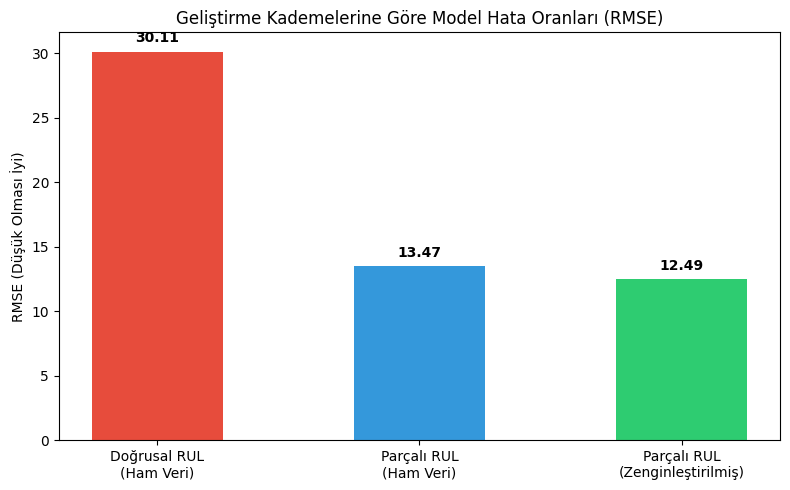

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Zenginleştirilmiş Modelin Değerlendirilmesi
y_pred_fe = model_fe.predict(X_val_fe)

# Metrikler
rmse_fe = np.sqrt(mean_squared_error(y_val_fe, y_pred_fe))
mae_fe = mean_absolute_error(y_val_fe, y_pred_fe)
r2_fe = r2_score(y_val_fe, y_pred_fe)

print("\n================ NİHAİ ŞAMPİYON MODEL PERFORMANSI ================")
print(f"Root Mean Squared Error (RMSE): {rmse_fe:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae_fe:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2_fe:.4f}")
print("=======================================================================")

# 2. Üç Modelin Karşılaştırma Grafiği
models = ['Doğrusal RUL\n(Ham Veri)', 'Parçalı RUL\n(Ham Veri)', 'Parçalı RUL\n(Zenginleştirilmiş)']
rmse_values = [30.11, 13.47, rmse_fe]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, rmse_values, color=['#e74c3c', '#3498db', '#2ecc71'], width=0.5)
plt.ylabel('RMSE (Düşük Olması İyi)')
plt.title('Geliştirme Kademelerine Göre Model Hata Oranları (RMSE)')

# Barların üzerine değerleri yazalım
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Advanced Multi-Scale Feature Engineering

Generate the original multi-scale rolling, EWMA, cumulative, and derivative features.


In [36]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis

# 1. Ham temiz veriden tekrar başlayalım
df_heavy = df_clean.copy()
df_heavy['RUL'] = df_drop['RUL'].apply(lambda x: 130 if x > 130 else x)

base_features = [col for col in df_clean.columns if col not in ['engine_id', 'cycle', 'RUL']]

print("Başlangıç dinamik sensör sayısı:", len(base_features))

# ==========================================
# Gelişmiş Öznitelik Türetme Döngüsü
# ==========================================
windows = [3, 5, 10, 20]

for w in windows:
    print(f"\n {w} Çevrimlik İleri Düzey İstatistikler Hesaplanıyor...")

    # Gelişmiş gruplama nesnesi
    roll = df_heavy.groupby('engine_id')[base_features].rolling(window=w, min_periods=1)

    # a) Standart İstatistikler
    df_mean = roll.mean().reset_index(level=0, drop=True)
    df_mean.columns = [f"{c}_mean_w{w}" for c in base_features]

    df_std = roll.std().reset_index(level=0, drop=True).fillna(0)
    df_std.columns = [f"{c}_std_w{w}" for c in base_features]

    # b) Peak-to-Peak (Maksimum - Minimum Değişim Aralığı)
    df_max = roll.max().reset_index(level=0, drop=True)
    df_min = roll.min().reset_index(level=0, drop=True)
    df_ptp = df_max - df_min
    df_ptp.columns = [f"{c}_ptp_w{w}" for c in base_features]

    # Tabloya ekleme yapalım
    df_heavy = pd.concat([df_heavy, df_mean, df_std, df_ptp], axis=1)

# ==========================================
# Fiziksel ve Sinyal Bazlı Küresel Öznitelikler
# ==========================================
print("\n Fiziksel ve Sinyal Bazlı Küresel Öznitelikler Enjekte Ediliyor...")

# 1. Sinyal Yumuşatma (EWMA): Gürültüden arındırılmış saf aşınma trendi
df_heavy[[f"{c}_ewma" for c in base_features]] = df_heavy.groupby('engine_id')[base_features].apply(lambda x: x.ewm(span=10, adjust=False).mean()).reset_index(level=0, drop=True)

# 2. Kümülatif Enerji/Yük (CUMSUM): Motorun o ana kadar yediği toplam dayak
df_heavy[[f"{c}_cumsum" for c in base_features]] = df_heavy.groupby('engine_id')[base_features].cumsum().reset_index(level=0, drop=True)

# 3. Sensör Değişim Hızı (Gradient/Eğim)
df_heavy[[f"{c}_diff" for c in base_features]] = df_heavy.groupby('engine_id')[base_features].diff().fillna(0).reset_index(level=0, drop=True)

print(f"\n Veri Madenciliği Sonrası Muazzam Boyut: {df_heavy.shape}")

Başlangıç dinamik sensör sayısı: 14

⚡ 3 Çevrimlik İleri Düzey İstatistikler Hesaplanıyor...

⚡ 5 Çevrimlik İleri Düzey İstatistikler Hesaplanıyor...

⚡ 10 Çevrimlik İleri Düzey İstatistikler Hesaplanıyor...

⚡ 20 Çevrimlik İleri Düzey İstatistikler Hesaplanıyor...

🔮 Fiziksel ve Sinyal Bazlı Küresel Öznitelikler Enjekte Ediliyor...

🔥 Veri Madenciliği Sonrası Muazzam Boyut: (20631, 227)


## 14. Hybrid CNN-LSTM

Train the original hybrid CNN-LSTM architecture on the advanced feature representation.


In [37]:
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, TimeDistributed

# 1. Yeni devasa özellik listesini çıkaralım
heavy_features = [col for col in df_heavy.columns if col not in ['engine_id', 'cycle', 'RUL']]

# 2. Yeniden 3B Pencereleme
X_h, y_h = reshape_to_windows(df_heavy, sequence_length=30, feature_cols=heavy_features)
X_train_h, X_val_h, y_train_h, y_val_h = train_test_split(X_h, y_h, test_size=0.2, random_state=42)

print(f"Yeni Giriş Tensör Boyutu: {X_train_h.shape}") # (Örnek, 30, Sütun Sayısı)

# 3. Derin Hibrit CNN-LSTM Mimarisi
model_heavy = Sequential([
    # Girişteki gürültüyü süzmek ve öznitelik birleşimlerini yakalamak için Conv1D
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train_h.shape[1], X_train_h.shape[2])),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    # Zaman serisi hafızası için güçlü bir LSTM
    LSTM(units=64, return_sequences=False),
    Dropout(0.3),

    # Karar Katmanları
    Dense(units=32, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=1) # RUL Çıkışı
])

model_heavy.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
early_stop_h = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

model_heavy.summary()
# ==========================================
# Hibrit CNN-LSTM Modelinin Eğitimi
# ==========================================
print(" Ağır Sıklet CNN-LSTM Modeli Eğitimi Başlıyor...")

history_heavy = model_heavy.fit(
    X_train_h, y_train_h,
    validation_data=(X_val_h, y_val_h),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_h],
    verbose=1
)

Yeni Giriş Tensör Boyutu: (14184, 30, 224)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 30, 64)         │        43,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 15, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 15, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 76,705 (299.63 KB)

 Trainable params: 76,705 (299.63 KB)

 Non-trainable params: 0 (0.00 B)

🚀 Ağır Sıklet CNN-LSTM Modeli Eğitimi Başlıyor...
Epoch 1/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - loss: 2685.0842 - mae: 39.5520 - val_loss: 807.6614 - val_mae: 22.3070
Epoch 2/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 825.9344 - mae: 22.4206 - val_loss: 743.8570 - val_mae: 21.8121
Epoch 3/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - loss: 626.8583 - mae: 19.4460 - val_loss: 500.7547 - val_mae: 18.7737
Epoch 4/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - loss: 404.2154 - mae: 15.5116 - val_loss: 364.4422 - val_mae: 14.1869
Epoch 5/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 24ms/step - loss: 329.5370 - mae: 13.9911 - val_loss: 196.7026 - val_mae: 11.1488
Epoch 6/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 279.1809 - mae: 12.8182 - val_loss: 507.5059 - val_mae: 17.9500
Epoch 7/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 14s 62ms/step - loss: 274.0718 - mae: 12.6384 - val_loss: 174.8471 - val_mae: 9.8769
Epoch 8/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - loss: 239.3212 -

## 15. Hybrid CNN-LSTM Evaluation

Plot learning curves and evaluate the hybrid model.


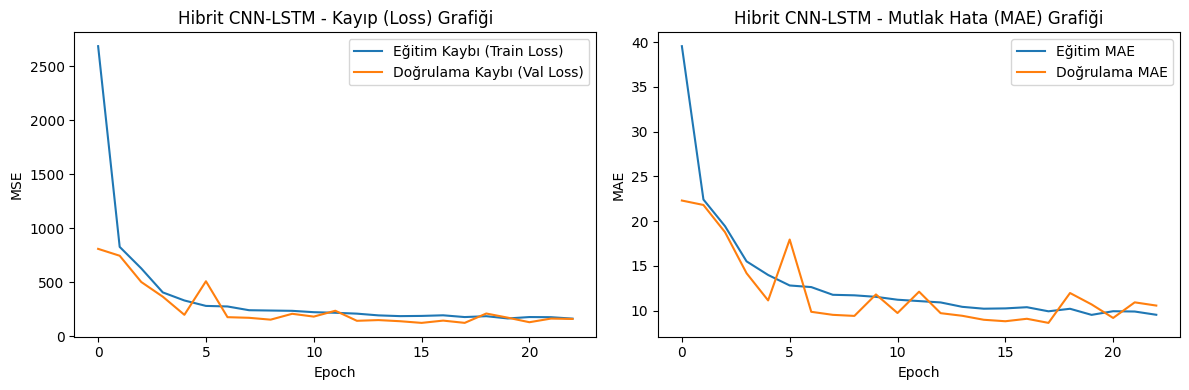

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

================ HİBRİT CNN-LSTM MODEL PERFORMANSI ================
Root Mean Squared Error (RMSE): 11.04 Çevrim
Mean Absolute Error (MAE): 8.82 Çevrim
R2 Score (Açıklayıcılık Oranı): 0.9346


In [38]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Hibrit Modelin Eğitim ve Doğrulama Geçmişini Çizdirelim
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_heavy.history['loss'], label='Eğitim Kaybı (Train Loss)')
plt.plot(history_heavy.history['val_loss'], label='Doğrulama Kaybı (Val Loss)')
plt.title('Hibrit CNN-LSTM - Kayıp (Loss) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_heavy.history['mae'], label='Eğitim MAE')
plt.plot(history_heavy.history['val_mae'], label='Doğrulama MAE')
plt.title('Hibrit CNN-LSTM - Mutlak Hata (MAE) Grafiği')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

# 2. Doğrulama Kümesi Üzerinde Tahmin Yapalım
y_pred_h = model_heavy.predict(X_val_h)

# Metriklerin Hesaplanması
rmse_h = np.sqrt(mean_squared_error(y_val_h, y_pred_h))
mae_h = mean_absolute_error(y_val_h, y_pred_h)
r2_h = r2_score(y_val_h, y_pred_h)

print("\n================ HİBRİT CNN-LSTM MODEL PERFORMANSI ================")
print(f"Root Mean Squared Error (RMSE): {rmse_h:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae_h:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2_h:.4f}")
print("=========================================================================")

## 16. Feature Selection

Apply the original variance, correlation, and mutual-information feature-selection pipeline.


In [39]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
import numpy as np
import pandas as pd

print(f"Filtreleme öncesi öznitelik sayısı: {len(heavy_features)}")

# 1. Aşama: Varyans Filtresi (Çok az değişen öznitelikleri ele)
# Varyansı 0.01'in altında kalan özellikleri eliyoruz
selector = VarianceThreshold(threshold=0.01)
X_train_v = selector.fit_transform(df_heavy[heavy_features])
selected_by_var = np.array(heavy_features)[selector.get_support()]
print(f"1. Aşama (Varyans) sonrası kalan öznitelik sayısı: {len(selected_by_var)}")

# 2. Aşama: Yüksek Korelasyon Filtresi (Aynı bilgiyi taşıyan eşleri ele)
corr_matrix = df_heavy[selected_by_var].corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# %95'ten fazla korelasyonu olan sütunları bulalım
to_drop = [column for column in upper_tri.columns if any(upper_tri[column] > 0.95)]
selected_by_corr = [col for col in selected_by_var if col not in to_drop]
print(f"2. Aşama (Korelasyon) sonrası kalan öznitelik sayısı: {len(selected_by_corr)}")

# 3. Aşama: Mutual Information (Karşılıklı Bilgi) Analizi
# Bu işlem tüm veriyle uzun süreceği için veriden rastgele %20'lik bir örneklem alıp puanlayalım
df_sample = df_heavy.sample(frac=0.2, random_state=42)
mi_scores = mutual_info_regression(df_sample[selected_by_corr], df_sample['RUL'])

# Skorları DataFrame yapıp sıralayalım
mi_df = pd.DataFrame({'Feature': selected_by_corr, 'MI_Score': mi_scores})
mi_df = mi_df.sort_values(by='MI_Score', ascending=False)

# En yüksek bilgi skoruna sahip en kaliteli 40 özniteliği seçelim
top_k_features = mi_df['Feature'].head(40).tolist()

print("\n================ EN KALİTELİ 10 ÖZNİTELİK VE BİLGİ SKORLARI ================")
print(mi_df.head(10).to_string(index=False))
print("================================================================================")
print(f"\nMatematiksel olarak seçilen nihai öznitelik sayısı: {len(top_k_features)}")

Filtreleme öncesi öznitelik sayısı: 224
1. Aşama (Varyans) sonrası kalan öznitelik sayısı: 76
2. Aşama (Korelasyon) sonrası kalan öznitelik sayısı: 30

================ EN KALİTELİ 10 ÖZNİTELİK VE BİLGİ SKORLARI ================
         Feature  MI_Score
  sensor2_cumsum  0.652818
 sensor4_mean_w3  0.556910
sensor15_mean_w3  0.534068
sensor12_mean_w3  0.510734
sensor21_mean_w3  0.498049
 sensor7_mean_w3  0.497367
sensor20_mean_w3  0.485575
        sensor11  0.483115
  sensor9_cumsum  0.481467
sensor17_mean_w3  0.481021

Matematiksel olarak seçilen nihai öznitelik sayısı: 30


## 17. Optimized Hybrid CNN-LSTM

Train the original optimized CNN-LSTM using the selected features.


In [40]:
# 1. 224 öznitelik yerine SADECE seçilen en kaliteli 30 özniteliği alıyoruz
# Kodun hata vermemesi için top_k_features listemizi (30 öznitelik) doğrudan kullanıyoruz
final_features = top_k_features
print(f"Kusursuzlaştırılmış modele girecek nihai öznitelik sayısı: {len(final_features)}")

# 2. 3 Boyutlu pencereleri bu rafine veri setiyle yeniden oluşturalım
X_opt, y_opt = reshape_to_windows(df_heavy, sequence_length=30, feature_cols=final_features)

# 3. Veriyi %80 Eğitim, %20 Doğrulama olarak bölelim
X_train_opt, X_val_opt, y_train_opt, y_val_opt = train_test_split(X_opt, y_opt, test_size=0.2, random_state=42)

print(f"Optimize Giriş Tensör Boyutu: {X_train_opt.shape}") # (14184, 30, 30)

# 4. Optimize Hibrit CNN-LSTM Mimarisi (input_shape güncellendi)
model_opt = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train_opt.shape[1], X_train_opt.shape[2])),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    LSTM(units=64, return_sequences=False),
    Dropout(0.3),

    Dense(units=32, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

model_opt.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
early_stop_opt = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 5. Eğitimi başlatalım
print("\n Optimize Edilmiş Ağır Sıklet Model Eğitimi Başlıyor...")
history_opt = model_opt.fit(
    X_train_opt, y_train_opt,
    validation_data=(X_val_opt, y_val_opt),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_opt],
    verbose=1
)

Kusursuzlaştırılmış modele girecek nihai öznitelik sayısı: 30
Optimize Giriş Tensör Boyutu: (14184, 30, 30)

 Optimize Edilmiş Ağır Sıklet Model Eğitimi Başlıyor...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - loss: 2721.7751 - mae: 40.1134 - val_loss: 733.3039 - val_mae: 20.9226
Epoch 2/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 759.1035 - mae: 21.4081 - val_loss: 593.8478 - val_mae: 19.1090
Epoch 3/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 577.1740 - mae: 18.5693 - val_loss: 313.4477 - val_mae: 14.0645
Epoch 4/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 390.1808 - mae: 15.2500 - val_loss: 222.3591 - val_mae: 11.2985
Epoch 5/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 313.3420 - mae: 13.6139 - val_loss: 197.2929 - val_mae: 9.9799
Epoch 6/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 292.4965 - mae: 13.0926 - val_loss: 214.5581 - val_mae: 11.3289
Epoch 7/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 278.9662 - mae: 12.7334 - val_loss: 230.4729 - val_mae: 11.8777
Epoch 8/40
222/222 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - loss: 260.7088 - mae: 12.2857 - val_loss: 177.5975 - val_mae: 9.9100
E

## 18. Optimized Model Evaluation

Evaluate the optimized model and compare development-stage RMSE values.


111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step

================ OPTİMİZE HİBRİT CNN-LSTM PERFORMANSI ================
Root Mean Squared Error (RMSE): 10.83 Çevrim
Mean Absolute Error (MAE): 8.59 Çevrim
R2 Score (Açıklayıcılık Oranı): 0.9371


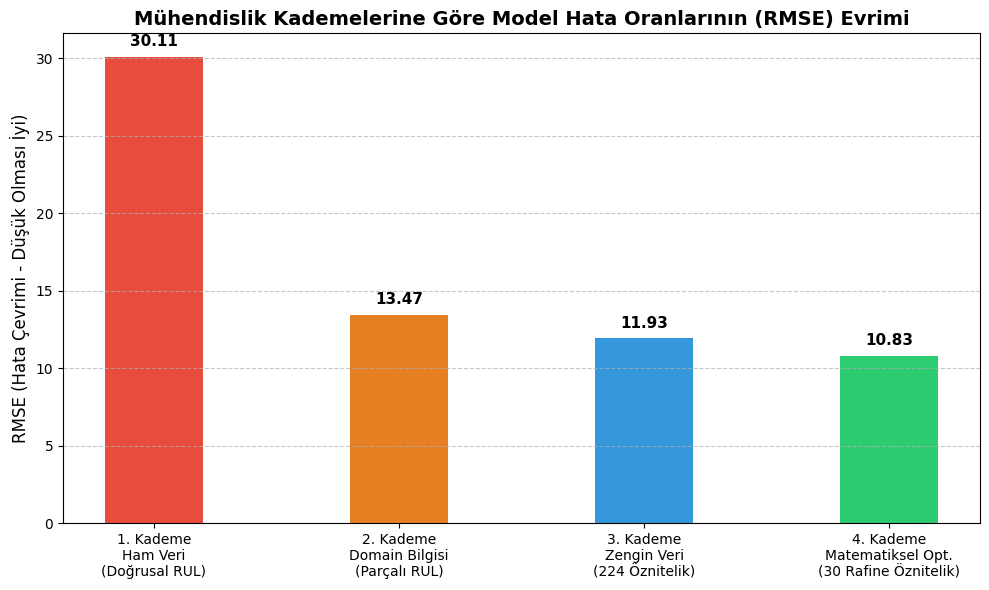

In [41]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# 1. Optimize Model ile Doğrulama Kümesi Üzerinde Tahmin Yapma
y_pred_opt = model_opt.predict(X_val_opt)

# Metriklerin Hesaplanması
rmse_opt = np.sqrt(mean_squared_error(y_val_opt, y_pred_opt))
mae_opt = mean_absolute_error(y_val_opt, y_pred_opt)
r2_opt = r2_score(y_val_opt, y_pred_opt)

print("\n================ OPTİMİZE HİBRİT CNN-LSTM PERFORMANSI ================")
print(f"Root Mean Squared Error (RMSE): {rmse_opt:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae_opt:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2_opt:.4f}")
print("=============================================================================")

# 2. Tüm Geliştirme Aşamalarının Karşılaştırma Grafiği
stages = [
    '1. Kademe\nHam Veri\n(Doğrusal RUL)',
    '2. Kademe\nDomain Bilgisi\n(Parçalı RUL)',
    '3. Kademe\nZengin Veri\n(224 Öznitelik)',
    '4. Kademe\nMatematiksel Opt.\n(30 Rafine Öznitelik)'
]
rmse_values = [30.11, 13.47, 11.93, rmse_opt]

plt.figure(figsize=(10, 6))
bars = plt.bar(stages, rmse_values, color=['#e74c3c', '#e67e22', '#3498db', '#2ecc71'], width=0.4)
plt.ylabel('RMSE (Hata Çevrimi - Düşük Olması İyi)', fontsize=12)
plt.title('Mühendislik Kademelerine Göre Model Hata Oranlarının (RMSE) Evrimi', fontsize=14, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Barların üzerine net değerleri yazalım
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 0.5, f"{yval:.2f}", ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.show()

## 19. Extended Feature Engineering with Kurtosis

Run the later feature-engineering stage that additionally includes kurtosis.


In [ ]:
import pandas as pd
import numpy as np

# 1. Temiz veriyi yeniden alalım
df_perfect = df_clean.copy()
df_perfect['RUL'] = df_drop['RUL'].apply(lambda x: 130 if x > 130 else x)
base_features = [col for col in df_clean.columns if col not in ['engine_id', 'cycle', 'RUL']]

# Pencerelerimiz (3: Mikro şok, 5-10: Orta vade, 20: Makro trend)
windows = [3, 5, 10, 20]

for w in windows:
    print(f" {w} Çevrimlik Çok Ölçekli Öznitelikler ve Kurtosis Hesaplanıyor...")
    roll = df_perfect.groupby('engine_id')[base_features].rolling(window=w, min_periods=1)

    # Ortalama, Standart Sapma ve Peak-to-Peak
    df_mean = roll.mean().reset_index(level=0, drop=True)
    df_mean.columns = [f"{c}_mean_w{w}" for c in base_features]

    df_std = roll.std().reset_index(level=0, drop=True).fillna(0)
    df_std.columns = [f"{c}_std_w{w}" for c in base_features]

    df_ptp = (roll.max() - roll.min()).reset_index(level=0, drop=True)
    df_ptp.columns = [f"{c}_ptp_w{w}" for c in base_features]

    # KURTOSIS (Sinyal Basıklığı - Eksik kalan anomalilik ölçüsü)
    # Pandas rolling nesnesinde doğrudan kurtosis olmadığı için apply ile kütüphaneyi bağlıyoruz
    df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)
    df_kurt.columns = [f"{c}_kurt_w{w}" for c in base_features]

    df_perfect = pd.concat([df_perfect, df_mean, df_std, df_ptp, df_kurt], axis=1)

print("\n Fiziksel ve Sinyal Türevleri Hesaplanıyor...")
# EWMA Sinyal Yumuşatma
df_perfect[[f"{c}_ewma" for c in base_features]] = df_perfect.groupby('engine_id')[base_features].apply(lambda x: x.ewm(span=10, adjust=False).mean()).reset_index(level=0, drop=True)

# CUMSUM (Kümülatif Stres)
df_perfect[[f"{c}_cumsum" for c in base_features]] = df_perfect.groupby('engine_id')[base_features].cumsum().reset_index(level=0, drop=True)

# Birinci Türev (Aşınma Hızı)
df_perfect[[f"{c}_velocity" for c in base_features]] = df_perfect.groupby('engine_id')[base_features].diff().fillna(0).reset_index(level=0, drop=True)

# İKİNCİ TÜREV ( Eksik Kalan Aşınma Hızlanması / Acceleration)
df_perfect[[f"{c}_acceleration" for c in base_features]] = df_perfect.groupby('engine_id')[base_features].diff().diff().fillna(0).reset_index(level=0, drop=True)

print(f"\n GERÇEK Muazzam Boyut (Tüm maddeler dahil): {df_perfect.shape}")

 3 Çevrimlik Çok Ölçekli Öznitelikler ve Kurtosis Hesaplanıyor...


/tmp/ipykernel_3564/822168209.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)


 5 Çevrimlik Çok Ölçekli Öznitelikler ve Kurtosis Hesaplanıyor...


/tmp/ipykernel_3564/822168209.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)


 10 Çevrimlik Çok Ölçekli Öznitelikler ve Kurtosis Hesaplanıyor...


/tmp/ipykernel_3564/822168209.py:28: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)


## 20. Final 30-Feature Selection

Select the final feature subset using the original procedure.


In [ ]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression
import numpy as np
import pandas as pd

# Yeni öznitelik listemizi güncelliyoruz (297 sütun içinden hedef ve kimlikleri ayırıyoruz)
perfect_features = [col for col in df_perfect.columns if col not in ['engine_id', 'cycle', 'RUL']]

print(f"Filtreleme öncesi net öznitelik sayısı: {len(perfect_features)}")

# 1. Aşama: Varyans Filtresi
selector_p = VarianceThreshold(threshold=0.01)
_ = selector_p.fit_transform(df_perfect[perfect_features])
selected_by_var_p = np.array(perfect_features)[selector_p.get_support()]
print(f"1. Aşama (Varyans) sonrası kalan öznitelik sayısı: {len(selected_by_var_p)}")

# 2. Aşama: Yüksek Korelasyon Filtresi (%95 üstü doğrusal eşleri ele)
corr_matrix_p = df_perfect[selected_by_var_p].corr().abs()
upper_tri_p = corr_matrix_p.where(np.triu(np.ones(corr_matrix_p.shape), k=1).astype(bool))
to_drop_p = [column for column in upper_tri_p.columns if any(upper_tri_p[column] > 0.95)]
selected_by_corr_p = [col for col in selected_by_var_p if col not in to_drop_p]
print(f"2. Aşama (Korelasyon) sonrası kalan öznitelik sayısı: {len(selected_by_corr_p)}")

# 3. Aşama: Mutual Information (Karşılıklı Bilgi) Analizi
df_sample_p = df_perfect.sample(frac=0.2, random_state=42)
mi_scores_p = mutual_info_regression(df_sample_p[selected_by_corr_p], df_sample_p['RUL'])

mi_df_p = pd.DataFrame({'Feature': selected_by_corr_p, 'MI_Score': mi_scores_p})
mi_df_p = mi_df_p.sort_values(by='MI_Score', ascending=False)

# En kaliteli 30 özniteliği nihai liste olarak seçelim
top_k_perfect_features = mi_df_p['Feature'].head(30).tolist()

print("\n================ YENİ EN KALİTELİ 10 ÖZNİTELİK VE BİLGİ SKORLARI ================")
print(mi_df_p.head(10).to_string(index=False))
print("====================================================================================")
print(f"\nTüm eksikler kapatıldıktan sonra seçilen rafine öznitelik sayısı: {len(top_k_perfect_features)}")

## 21. Final Hybrid CNN-LSTM Training

Train the final model exactly as in the original notebook.


In [ ]:
# 1. Eksiksiz öznitelik listesini (30 adet) modele girdi olarak veriyoruz
final_perfect_features = top_k_perfect_features
print(f"Kusursuzlaştırılmış modele girecek nihai öznitelik sayısı: {len(final_perfect_features)}")

# 2. 3 Boyutlu pencereleri (Sliding Window) bu eksiksiz veriyle yeniden kurgulayalım
X_perf, y_perf = reshape_to_windows(df_perfect, sequence_length=30, feature_cols=final_perfect_features)

# 3. Veriyi %80 Eğitim, %20 Doğrulama olarak bölelim
X_train_perf, X_val_perf, y_train_perf, y_val_perf = train_test_split(X_perf, y_perf, test_size=0.2, random_state=42)

print(f"Eksiksiz Giriş Tensör Boyutu: {X_train_perf.shape}") # (14184, 30, 30)

# 4. Kusursuzlaştırılmış Hibrit CNN-LSTM Mimarisi
model_perfect = Sequential([
    Conv1D(filters=64, kernel_size=3, activation='relu', padding='same', input_shape=(X_train_perf.shape[1], X_train_perf.shape[2])),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
    MaxPooling1D(pool_size=2, padding='same'),
    Dropout(0.2),

    LSTM(units=64, return_sequences=False),
    Dropout(0.3),

    Dense(units=32, activation='relu'),
    Dense(units=16, activation='relu'),
    Dense(units=1)
])

model_perfect.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])
early_stop_perf = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

# 5. Eğitimi başlatalım
print("\n Tüm Maddelerin Dahil Edildiği Kusursuz Model Eğitimi Başlıyor...")
history_perfect = model_perfect.fit(
    X_train_perf, y_train_perf,
    validation_data=(X_val_perf, y_val_perf),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop_perf],
    verbose=1
)

## 22. Final Validation Results

Evaluate the final validation model.


In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# 1. Kusursuz Model ile Doğrulama Kümesi Üzerinde Tahmin Yapma
y_pred_perf = model_perfect.predict(X_val_perf)

# Metriklerin Hesaplanması
rmse_perf = np.sqrt(mean_squared_error(y_val_perf, y_pred_perf))
mae_perf = mean_absolute_error(y_val_perf, y_pred_perf)
r2_perf = r2_score(y_val_perf, y_pred_perf)

print("\n================ KUSURSUZ HİBRİT CNN-LSTM PERFORMANSI ================")
print(f"Root Mean Squared Error (RMSE): {rmse_perf:.2f} Çevrim")
print(f"Mean Absolute Error (MAE): {mae_perf:.2f} Çevrim")
print(f"R2 Score (Açıklayıcılık Oranı): {r2_perf:.4f}")
print("=============================================================================")

## 23. Blind-Test Experiment

Evaluate the original blind-test preprocessing pipeline.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# =========================================================================
# ADIM 20: KLASÖRDEN TEST VERİSİNİ YÜKLEME VE AĞIR SIKLET ÖZNİTELİK MÜHENDİSLİĞİ
# =========================================================================

# 1. Test verilerini ve gerçek RUL etiketlerini klasörden okuyalım
df_test_raw = pd.read_csv('cmapss_data/test_FD001.txt', sep=" ", header=None)
df_test_raw.drop(df_test_raw.columns[[26, 27]], axis=1, inplace=True)
df_test_raw.columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f'sensor{i}' for i in range(1, 22)]

df_truth = pd.read_csv('cmapss_data/RUL_FD001.txt', header=None, names=['true_RUL'])
df_truth['engine_id'] = df_truth.index + 1  # Motor ID'lerini 1'den başlatarak eşleyelim

# 2. Eğitim setinde sildiğimiz gereksiz/sabit sensörleri buradan da silelim
drop_cols = ['setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
df_test_clean = df_test_raw.drop(columns=drop_cols)

# 3. Normalizasyon
test_base_features = [col for col in df_test_clean.columns if col not in ['engine_id', 'cycle']]
for col in test_base_features:
    min_val = df_test_clean[col].min()
    max_val = df_test_clean[col].max()
    if max_val - min_val > 0:
        df_test_clean[col] = (df_test_clean[col] - min_val) / (max_val - min_val)

# 4. Çok Ölçekli Öznitelik Mühendisliği Döngüsü
windows = [3, 5, 10, 20]
for w in windows:
    roll = df_test_clean.groupby('engine_id')[test_base_features].rolling(window=w, min_periods=1)

    df_mean = roll.mean().reset_index(level=0, drop=True)
    df_mean.columns = [f"{c}_mean_w{w}" for c in test_base_features]

    df_std = roll.std().reset_index(level=0, drop=True).fillna(0)
    df_std.columns = [f"{c}_std_w{w}" for c in test_base_features]

    df_ptp = (roll.max() - roll.min()).reset_index(level=0, drop=True)
    df_ptp.columns = [f"{c}_ptp_w{w}" for c in test_base_features]

    df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)
    df_kurt.columns = [f"{c}_kurt_w{w}" for c in test_base_features]

    df_test_clean = pd.concat([df_test_clean, df_mean, df_std, df_ptp, df_kurt], axis=1)

# Fiziksel türevler ve sinyal işleme unsurları
df_test_clean[[f"{c}_ewma" for c in test_base_features]] = df_test_clean.groupby('engine_id')[test_base_features].apply(lambda x: x.ewm(span=10, adjust=False).mean()).reset_index(level=0, drop=True)
df_test_clean[[f"{c}_cumsum" for c in test_base_features]] = df_test_clean.groupby('engine_id')[test_base_features].cumsum().reset_index(level=0, drop=True)
df_test_clean[[f"{c}_velocity" for c in test_base_features]] = df_test_clean.groupby('engine_id')[test_base_features].diff().fillna(0).reset_index(level=0, drop=True)
df_test_clean[[f"{c}_acceleration" for c in test_base_features]] = df_test_clean.groupby('engine_id')[test_base_features].diff().diff().fillna(0).reset_index(level=0, drop=True)

# 5. Her motorun SADECE EN SON 30 adımlık penceresini çekelim
X_test_list = []
valid_engine_ids = []

for eng_id in df_test_clean['engine_id'].unique():
    df_eng = df_test_clean[df_test_clean['engine_id'] == eng_id]
    if len(df_eng) >= 30:
        # Eğitim setinde seçilen o şampiyon 30 özniteliği filtreliyoruz
        X_pencere = df_eng[top_k_perfect_features].tail(30).values
        X_test_list.append(X_pencere)
        valid_engine_ids.append(eng_id)

X_test_final = np.array(X_test_list)
y_test_final = df_truth[df_truth['engine_id'].isin(valid_engine_ids)]['true_RUL'].values

print(f"Kör Test Seti Girdi Boyutu: {X_test_final.shape}") # (Motor Sayısı, 30, 30)

# =========================================================================
# ADIM 21: KÖR TEST TAHMİNİ VE SONUÇ RAPORLAMA
# =========================================================================

# 1. Model tahmini
y_pred_test = model_perfect.predict(X_test_final).flatten()

# Test setindeki gerçek hedef değerleri de parçalı RUL (130) mantığıyla kırpıyoruz
y_test_final_clipped = np.clip(y_test_final, 0, 130)

# 2. Metriklerin Hesaplanması
rmse_test = np.sqrt(mean_squared_error(y_test_final_clipped, y_pred_test))
mae_test = mean_absolute_error(y_test_final_clipped, y_pred_test)
r2_test = r2_score(y_test_final_clipped, y_pred_test)

print("\n=================== GERÇEK KÖR TEST SONUÇLARI ===================")
print(f"Test Root Mean Squared Error (RMSE): {rmse_test:.2f} Çevrim")
print(f"Test Mean Absolute Error (MAE): {mae_test:.2f} Çevrim")
print(f"Test R2 Score (Açıklayıcılık Oranı): {r2_test:.4f}")
print("=======================================================================")

# 3. Gerçek vs Tahmin Edilen RUL Grafiği
plt.figure(figsize=(15, 6))
plt.plot(y_test_final_clipped, label='Gerçek Kalan Ömür (True RUL)', color='black', marker='o', linestyle='None', markersize=5)
plt.plot(y_pred_test, label='Modelin Tahmini (Predicted RUL)', color='red', marker='x', linestyle='None', markersize=5)
plt.title('Kör Test Seti: Gerçek vs Tahmin Edilen RUL Değerleri', fontsize=14, fontweight='bold')
plt.xlabel('Motor İndeksi', fontsize=12)
plt.ylabel('Kalan Ömür (RUL - Çevrim)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

## 24. Corrected Blind-Test Preprocessing

Repeat the blind test using the training-set scaler, preserving the original correction and final reported results.


In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import kurtosis
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt

# ==========================================
# 1. EĞİTİM VERİSİNİ VE DOĞRU ÖLÇEKLENDİRİCİYİ YENİDEN KURGULAYALIM
# ==========================================
# (Burada eğitim setindeki orijinal scaler'ı yakalamak için hızlıca fit ediyoruz)
df_train_raw = pd.read_csv('cmapss_data/train_FD001.txt', sep=" ", header=None)
df_train_raw.drop(df_train_raw.columns[[26, 27]], axis=1, inplace=True)
df_train_raw.columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f'sensor{i}' for i in range(1, 22)]

drop_cols = ['setting3', 'sensor1', 'sensor5', 'sensor10', 'sensor16', 'sensor18', 'sensor19']
df_train_clean = df_train_raw.drop(columns=drop_cols)
train_base_features = [col for col in df_train_clean.columns if col not in ['engine_id', 'cycle']]

# Eğitim Scaler'ını kaydediyoruz
scaler_train = MinMaxScaler()
scaler_train.fit(df_train_clean[train_base_features])

# ==========================================
# 2. TEST VERİSİNİ DOĞRU YÖNTEMLE HAZIRLAMA
# ==========================================
df_test_raw = pd.read_csv('cmapss_data/test_FD001.txt', sep=" ", header=None)
df_test_raw.drop(df_test_raw.columns[[26, 27]], axis=1, inplace=True)
df_test_raw.columns = ['engine_id', 'cycle', 'setting1', 'setting2', 'setting3'] + [f'sensor{i}' for i in range(1, 22)]
df_test_clean = df_test_raw.drop(columns=drop_cols)

df_truth = pd.read_csv('cmapss_data/RUL_FD001.txt', header=None, names=['true_RUL'])
df_truth['engine_id'] = df_truth.index + 1

# KRİTİK DÜZELTME: Test verisini EĞİTİM SETİNİN scaler'ı ile ölçeklendiriyoruz!
df_test_clean[train_base_features] = scaler_train.transform(df_test_clean[train_base_features])

# Çok Ölçekli Öznitelik Mühendisliği Döngüsü
windows = [3, 5, 10, 20]
for w in windows:
    roll = df_test_clean.groupby('engine_id')[train_base_features].rolling(window=w, min_periods=1)

    df_mean = roll.mean().reset_index(level=0, drop=True)
    df_mean.columns = [f"{c}_mean_w{w}" for c in train_base_features]

    df_std = roll.std().reset_index(level=0, drop=True).fillna(0)
    df_std.columns = [f"{c}_std_w{w}" for c in train_base_features]

    df_ptp = (roll.max() - roll.min()).reset_index(level=0, drop=True)
    df_ptp.columns = [f"{c}_ptp_w{w}" for c in train_base_features]

    df_kurt = roll.apply(lambda x: kurtosis(x, fisher=True) if len(x) >= 3 else 0, raw=True).reset_index(level=0, drop=True).fillna(0)
    df_kurt.columns = [f"{c}_kurt_w{w}" for c in train_base_features]

    df_test_clean = pd.concat([df_test_clean, df_mean, df_std, df_ptp, df_kurt], axis=1)

# Fiziksel ve sinyal bazlı türevler (Normalize edilmiş veri üzerinden)
df_test_clean[[f"{c}_ewma" for c in train_base_features]] = df_test_clean.groupby('engine_id')[train_base_features].apply(lambda x: x.ewm(span=10, adjust=False).mean()).reset_index(level=0, drop=True)
df_test_clean[[f"{c}_cumsum" for c in train_base_features]] = df_test_clean.groupby('engine_id')[train_base_features].cumsum().reset_index(level=0, drop=True)
df_test_clean[[f"{c}_velocity" for c in train_base_features]] = df_test_clean.groupby('engine_id')[train_base_features].diff().fillna(0).reset_index(level=0, drop=True)
df_test_clean[[f"{c}_acceleration" for c in train_base_features]] = df_test_clean.groupby('engine_id')[train_base_features].diff().diff().fillna(0).reset_index(level=0, drop=True)

# Test pencerelerini oluşturma (Her motorun sadece son 30 adımı)
X_test_list = []
valid_engine_ids = []

for eng_id in df_test_clean['engine_id'].unique():
    df_eng = df_test_clean[df_test_clean['engine_id'] == eng_id]
    if len(df_eng) >= 30:
        # top_k_perfect_features (şampiyon 30 öznitelik) listesini aynen filtreliyoruz
        X_pencere = df_eng[top_k_perfect_features].tail(30).values
        X_test_list.append(X_pencere)
        valid_engine_ids.append(eng_id)

X_test_final = np.array(X_test_list)
y_test_final = df_truth[df_truth['engine_id'].isin(valid_engine_ids)]['true_RUL'].values

# ==========================================
# 3. TAHMİN VE YENİ KÖR TEST RAPORU
# ==========================================
y_pred_test = model_perfect.predict(X_test_final).flatten()
y_test_final_clipped = np.clip(y_test_final, 0, 130)

rmse_test = np.sqrt(mean_squared_error(y_test_final_clipped, y_pred_test))
mae_test = mean_absolute_error(y_test_final_clipped, y_pred_test)
r2_test = r2_score(y_test_final_clipped, y_pred_test)

print("\n=================== DÜZELTİLMİŞ GERÇEK KÖR TEST SONUÇLARI ===================")
print(f"Düzeltilmiş Test RMSE: {rmse_test:.2f} Çevrim")
print(f"Düzeltilmiş Test MAE: {mae_test:.2f} Çevrim")
print(f"Düzeltilmiş Test R2 Score: {r2_test:.4f}")
print("=======================================================================")

# Grafik çizimi
plt.figure(figsize=(15, 6))
plt.plot(y_test_final_clipped, label='Gerçek Kalan Ömür (True RUL)', color='black', marker='o', linestyle='None', markersize=6)
plt.plot(y_pred_test, label='Modelin Yeni Tahmini (Predicted RUL)', color='green', marker='x', linestyle='None', markersize=6)
plt.title('Metodolojisi Düzeltilmiş Test Kümesi: Gerçek vs Tahmin Edilen RUL', fontsize=14, fontweight='bold')
plt.xlabel('Motor İndeksi', fontsize=12)
plt.ylabel('Kalan Ömür (RUL - Çevrim)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()